<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A3_Multivariate_Energy_RNN.ipynb)

# Advanced RNN Topics on the Demand Series
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

The upgrades from the *Advanced RNN Theory* notebook, applied to a real forecast: `Conv1D` + `MaxPooling1D` in front of the LSTM (ConvLSTM), recurrent dropout, stacking, and `Bidirectional`. One bake-off table at the end - because the point is not that these are fancier, it's whether they **beat the baselines and the plain LSTM**.

*Energy-track version of the temperature/occupancy advanced notebooks.*

**Module 4.3 · notebook 3 of 5** [A1 the primer](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A1_Primer_for_Advanced_Topics.ipynb)  →  [A2 univariate](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A2_Univariate_Temperature_Advanced.ipynb)  →  **A3 multivariate**  →  [A4 many-to-many](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A4_Many_to_Many_Energy.ipynb)  →  [A5 autoregressive](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A5_Multi_Step_Forecasting.ipynb)

**Next:** [`A4_Many_to_Many_Energy`](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A4_Many_to_Many_Energy.ipynb) changes the HEAD - two targets at once, then twenty-four hours at once.

> **Look-back here is 24 _hours_.** The data is hourly, so one day of history is the natural window. A2 used
> 30 _days_ because its data was daily. Same idea, different cadence.

> **This notebook is seeded.** `keras.utils.set_random_seed(5509)` is called at import **and again right
> before every model is built**, and `tf.config.experimental.enable_op_determinism()` forces the operations
> themselves to be deterministic. Run it a hundred times and you get the same numbers a hundred times.
>
> Why the seed is set more than once: a seed set only at import is *consumed* by everything that runs after it,
> so the second model you build would start from a different place than the first. Re-seeding before each build
> is what makes model 2 as reproducible as model 1.

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 14B — ConvLSTM, recurrent dropout and Bidirectional on the demand series
- Same tensors as the multivariate RNN notebook - the only thing that changes is the model.
- Conv1D(filters=32, kernel_size=3) on a (24, 8) window -> (22, 32); MaxPooling1D(2) -> (11, 32); the LSTM then spins 11 times, not 24. Read the shapes off summary().
- Recurrent dropout drops the SAME units at every time step; plain dropout would drop different ones. Both are regularizers - one respects the sequence.
- Bidirectional doubles the units (forward + backward). Say the honest caveat: for FORECASTING the backward pass sees nothing the forward pass didn't - the window is all past. It shines in text (Module 5).
- Bake-off table: persistence 129, plain LSTM ~51, ConvLSTM ~52, recurrent-dropout LSTM ~104 (regularizing a model that wasn't overfitting), stacked ~54, bidirectional ~40. The winner is whatever beats persistence by the most - and it is the one you just warned them about, so read it honestly: more units, not magic.
-->


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix
from keras.models import Sequential, load_model
from keras.layers import Input, Dense, Dropout, SimpleRNN, LSTM, GRU, Bidirectional, Conv1D, MaxPooling1D, Flatten
from keras.callbacks import EarlyStopping
import keras
keras.utils.set_random_seed(5509)          # seed numpy, python and tensorflow
tf.config.experimental.enable_op_determinism()   # ...and make the ops deterministic too, so re-running
                                                 # this notebook gives the SAME numbers

## Read, sort, split

In [2]:
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/BDL_cleanweather_energy.csv"
df = pd.read_csv(url, parse_dates=["Datetime"])
print("in date order as delivered?", df["Datetime"].is_monotonic_increasing)      # it is NOT - always check
df = df.sort_values("Datetime").set_index("Datetime").ffill()

# two years is plenty for the lecture: train on 2018, test on 2019 - chronological, never shuffled
data  = df.loc["2018-01-01":"2019-12-31", ["BDL_tmpf", "BDL_dwpf", "BDL_relh", "Demand"]].copy()
data["hour_sin"] = np.sin(2*np.pi*data.index.hour/24)
data["hour_cos"] = np.cos(2*np.pi*data.index.hour/24)
data["dow_sin"]  = np.sin(2*np.pi*data.index.dayofweek/7)
data["dow_cos"] = np.cos(2*np.pi*data.index.dayofweek/7)
data = data[["BDL_tmpf", "BDL_dwpf", "BDL_relh", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "Demand"]]   # Demand LAST
train, test = data.loc[:"2018-12-31"], data.loc["2019-01-01":]
print("train:", train.shape, "| test:", test.shape)
data.head()

in date order as delivered? False
train: (8760, 8) | test: (8760, 8)


,BDL_tmpf,BDL_dwpf,BDL_relh,hour_sin,hour_cos,dow_sin,dow_cos,Demand
Datetime,,,,,,,,
2018-01-01 00:00:00,1.9,0.0,56.85,0.000000,1.000000,0.0,1.0,3867.09
2018-01-01 01:00:00,0.0,0.0,62.12,0.258819,0.965926,0.0,1.0,3749.96
2018-01-01 02:00:00,0.0,0.0,61.38,0.500000,0.866025,0.0,1.0,3673.50
2018-01-01 03:00:00,0.0,0.0,71.11,0.707107,0.707107,0.0,1.0,3646.25
2018-01-01 04:00:00,0.0,0.0,64.21,0.866025,0.500000,0.0,1.0,3660.86


## Baselines

In [3]:
y = test["Demand"]
baselines = pd.Series({
    "mean-only":                       mean_absolute_error(y, np.full(len(y), train["Demand"].mean())),
    "seasonal naive (same hour yday)": mean_absolute_error(y.iloc[24:], y.shift(24).iloc[24:]),
    "persistence (last hour)":         mean_absolute_error(y.iloc[1:],  y.shift(1).iloc[1:]),
}, name="test MAE (MW)").round(1)
baselines

mean-only                          563.3
seasonal naive (same hour yday)    227.1
persistence (last hour)            129.0
Name: test MAE (MW), dtype: float64

## Prep (same as the multivariate RNN notebook)

<!-- WINDOW-FN -->
## The window-making function: `split_sequences`

Target in the **last column**, then:

- **`n_steps`** is the **look-back**: X is the last `n_steps` rows of **every column, the target included**. Yesterday's demand is the most useful input there is.
- y is the target **one step** after the window ends.

Result: X is `(samples, n_steps, n_features)`.


In [4]:
def split_sequences(seqs, n_steps):
    X, y = [], []
    for i in range(len(seqs) - n_steps):
        X.append(seqs[i:i+n_steps, :])
        y.append(seqs[i+n_steps, -1])   # inputs = EVERY column (demand's own past included); target = last col, NEXT step
    return np.array(X), np.array(y)

n_steps = 24
sc   = MinMaxScaler().fit(train)               # fit on TRAIN only
sc_y = MinMaxScaler().fit(train[["Demand"]])   # a separate scaler for the target so we can get MW back
tr_s, te_s = sc.transform(train), sc.transform(test)
X_train, y_train = split_sequences(tr_s, n_steps)
X_test,  y_test  = split_sequences(te_s, n_steps)
n_features = X_train.shape[2]
y_true = sc_y.inverse_transform(y_test.reshape(-1, 1)).ravel()   # test target in MW
print("train tensor:", X_train.shape, "-> (samples, look-back, features) | test:", X_test.shape)

train tensor: (8736, 24, 8) -> (samples, look-back, features) | test: (8736, 24, 8)


## What exactly is one sample?

One sample is a **24-hour block of every column**, and the model predicts **demand in the next hour**.

Two details that catch people:

1. **Demand's own past is an input here.** `split_sequences` keeps every column, demand included, so the model can
   lean on yesterday's shape. The occupancy notebook does the opposite and drops its target column.
2. **The target is the step after the window** - `seqs[i+n_steps, -1]` - so this is a one-hour-ahead forecast, not
   a nowcast.

In [5]:
cols = list(train.columns)
print("X shape:", X_train.shape, "= (samples, hours, features)   y shape:", y_train.shape)
print()
print(f"one sample - X_train[0] - is a {n_steps} x {len(cols)} block. Last 6 hours of it:")
row_labels = []
for i in range(5, -1, -1):
    row_labels.append("t-" + str(i))
display(pd.DataFrame(X_train[0][-6:], columns=cols, index=row_labels).round(3))
print(f"its label y_train[0] = {y_train[0]:.3f} (scaled) = "
      f"{sc_y.inverse_transform([[y_train[0]]])[0][0]:,.0f} MW  <- demand in the NEXT hour")

X shape: (8736, 24, 8) = (samples, hours, features)   y shape: (8736,)

one sample - X_train[0] - is a 24 x 8 block. Last 6 hours of it:


,BDL_tmpf,BDL_dwpf,BDL_relh,hour_sin,hour_cos,dow_sin,dow_cos,Demand
t-5,0.062,0.0,0.537,0.000,0.500,0.5,1.0,0.629
t-4,0.040,0.0,0.569,0.017,0.629,0.5,1.0,0.618
t-3,0.019,0.0,0.652,0.067,0.750,0.5,1.0,0.589
t-2,0.040,0.0,0.569,0.146,0.854,0.5,1.0,0.541
t-1,0.000,0.0,0.713,0.250,0.933,0.5,1.0,0.474
t-0,0.000,0.0,0.752,0.371,0.983,0.5,1.0,0.416


its label y_train[0] = 0.380 (scaled) = 3,734 MW  <- demand in the NEXT hour


## One helper to score every model

Every model below gets the same treatment so they are comparable: **test MAE in megawatts**, printed next to the
two baselines it has to beat, then two pictures - actual against predicted, and one week of the test year so you
can see *where* it goes wrong rather than just how much.

In [6]:
scores = {}

def show_results(name, pred, truth=None):
    """Score a demand model in MW, then show it two ways: actual vs predicted, and one test week."""
    truth = y_true if truth is None else truth
    mae = mean_absolute_error(truth, pred)
    scores[name] = round(mae, 1)
    print(f"{name}: test MAE = {mae:.1f} MW"
          f"   (persistence {baselines.iloc[2]:.1f}, seasonal naive {baselines.iloc[1]:.1f})")

    fig, ax = plt.subplots(1, 2, figsize=(12, 3.4), gridspec_kw={"width_ratios": [1, 2]})
    ax[0].scatter(truth, pred, s=3, alpha=0.3)
    lo, hi = min(np.min(truth), np.min(pred)), max(np.max(truth), np.max(pred))
    ax[0].plot([lo, hi], [lo, hi], "r--")
    ax[0].set_xlabel("actual (MW)")
    ax[0].set_ylabel("predicted (MW)")
    ax[0].set_title(name)
    i0 = 24 * 7 * 28                      # one week, deep enough into the test year to be interesting
    ax[1].plot(truth[i0:i0 + 24*7], label="actual", lw=1.4)
    ax[1].plot(pred[i0:i0 + 24*7], label=name, lw=1.1)
    ax[1].set_ylabel("MW")
    ax[1].set_xlabel("hour of one test week")
    ax[1].legend()
    plt.tight_layout()
    plt.show()

# Model 1 · The plain `LSTM` to beat

Start with the model from the multivariate notebook, unchanged, so every upgrade below has something honest to
be compared against. One sample is a **24 x 8 block** - 24 hours of demand, weather and the clock - and the
target is demand in the **next** hour.

| layer | output shape | parameters |
| :-- | :-- | --: |
| `LSTM(32)` | `(32,)` | 5,248 |
| `Dense(1)` | `(1,)` | 33 |
| | | **5,281** |

`4 x [32(32 + 8) + 32] = 5,248`: `g = 4` for an LSTM, `h = 32` hidden units, `i = 8` features. **The look-back
never appears** - 24 hours or 168, the layer is the same size.

Restoring model weights from the end of the best epoch: 50.


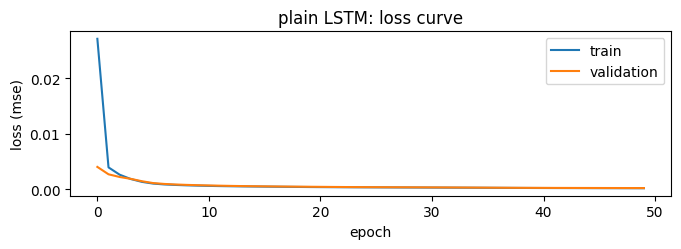

plain LSTM             stopped after 50 epochs; best val loss 0.00019


plain LSTM             params:   5281   test MAE: 50.7 MW


In [7]:
es = EarlyStopping(monitor="val_loss", patience=20, start_from_epoch=20,
                   restore_best_weights=True, verbose=1)

def fit(m, name):
    m.compile(optimizer="adam", loss="mse", metrics=["mae"])
    history = m.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2,
                    callbacks=[es], verbose=0)

    # the loss curve - always keep the History object that fit() hands back
    plt.figure(figsize=(7, 2.6))
    plt.plot(history.history["loss"], label="train")
    if "val_loss" in history.history:
        plt.plot(history.history["val_loss"], label="validation")
    plt.xlabel("epoch")
    plt.ylabel("loss (mse)")
    plt.title(f"{name}: loss curve")
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f"{name:22s} stopped after {len(history.history['loss'])} epochs;"
          f" best val loss {min(history.history['val_loss']):.5f}")
    pred = sc_y.inverse_transform(m.predict(X_test, verbose=0)).ravel()
    mae = mean_absolute_error(y_true, pred)
    print(f"{name:22s} params: {m.count_params():6d}   test MAE: {mae:.1f} MW")
    scores[name] = round(mae, 1)
    return m, pred, mae

keras.utils.set_random_seed(5509)   # re-seed before EVERY model, not just at import
plain = Sequential()
plain.add(Input(shape=(n_steps, n_features)))
plain.add(LSTM(32))
plain.add(Dense(1))
plain, pred_plain, mae_plain = fit(plain, "plain LSTM")

# Model 2 · ConvLSTM - `Conv1D` + `MaxPooling1D` in front of the LSTM

**The data prep did not change.** Two layers go in front of the recurrent one, and they make the sequence
**shorter and wider** before the LSTM ever sees it.

```
(24, 8)  --Conv1D(32, k=3)-->  (22, 32)  --MaxPooling1D(2)-->  (11, 32)
```

- A width-3 window fits into 24 hours only **22** times, and each of the 32 filters reads **all 8 features at
  once**, so `(24, 8)` becomes `(22, 32)`.
- Pooling keeps the larger of each adjacent pair. **No parameters at all**, and it halves the length again.
- The LSTM then spins **11 times instead of 24**, and its `i` is **32** - the filters, not the original 8
  features.

| layer | output shape | parameters | |
| :-- | :-- | --: | :-- |
| `Conv1D(32, k=3)` | `(22, 32)` | 800 | `32 x (3 x 8 + 1)` |
| `MaxPooling1D(2)` | `(11, 32)` | 0 | pure arithmetic |
| `LSTM(32)` | `(32,)` | 8,320 | `4 x [32(32 + 32) + 32]`, and `i = 32` now |
| `Dense(1)` | `(1,)` | 33 | |
| | | **9,153** | |

The LSTM got *bigger* even though its sequence got shorter, because the convolution widened what arrives at each
step. Worked through arrow by arrow in `A1_Primer_for_Advanced_Topics`.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 22, 32)         │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 11, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,153 (35.75 KB)

 Trainable params: 9,153 (35.75 KB)

 Non-trainable params: 0 (0.00 B)

Restoring model weights from the end of the best epoch: 50.


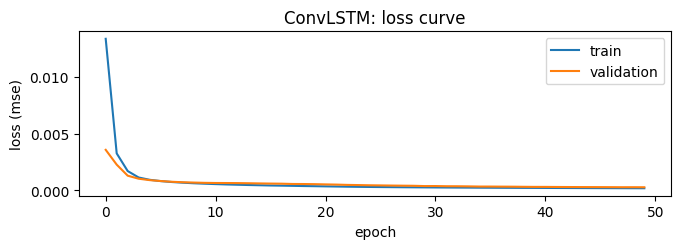

ConvLSTM               stopped after 50 epochs; best val loss 0.00027


ConvLSTM               params:   9153   test MAE: 50.1 MW


In [8]:
keras.utils.set_random_seed(5509)   # re-seed before EVERY model, not just at import
convlstm = Sequential()
convlstm.add(Input(shape=(n_steps, n_features)))
convlstm.add(Conv1D(filters=32, kernel_size=3, activation="relu"))    # (24, 8) -> (22, 32)
convlstm.add(MaxPooling1D(pool_size=2))    # (22, 32) -> (11, 32)
convlstm.add(LSTM(32))
convlstm.add(Dense(1))
convlstm.summary()
convlstm, pred_conv, mae_conv = fit(convlstm, "ConvLSTM")

# Model 3 · The two dropouts, and Model 4 · stacking

### Model 3: `dropout` and `recurrent_dropout` on one LSTM

Two different arguments, cutting two different sets of arrows - see the picture in
`A1_Primer_for_Advanced_Topics`:

- **`dropout=0.1`** cuts **input** arrows, the 8 features on their way into the layer.
- **`recurrent_dropout=0.2`** cuts **memory** arrows, the hidden state on its way from one hour to the next.

Both use **one mask for the whole sample** - the same units are silenced at every one of the 24 hours - which is
what makes it safe to do to a memory at all.

| layer | output shape | parameters |
| :-- | :-- | --: |
| `LSTM(32, dropout=0.1, recurrent_dropout=0.2)` | `(32,)` | 5,248 |
| `Dense(1)` | `(1,)` | 33 |
| | | **5,281** |

**Identical to Model 1.** Dropout is a switch, on during `fit` and off during `predict` - it never costs a
parameter.

⚠️ **`recurrent_dropout` is slow, and it is worth knowing why.** With `recurrent_dropout=0`, Keras runs the
whole 24-hour window through **one fused kernel** (cuDNN on a GPU, an optimized loop on CPU). Ask for recurrent
dropout and that fast path is gone: the layer falls back to a generic step-by-step loop, because the mask has to
be applied *inside* each step. 24 hours become 24 separate rounds of ops. Expect this cell to take several times
longer than the others for the same number of parameters.

### Model 4: stacking

`return_sequences=True` keeps all 24 hidden states so a second LSTM has a sequence to read. The second layer's
`i` is **32**, the width of the layer below it.

| layer | output shape | parameters | |
| :-- | :-- | --: | :-- |
| `LSTM(32, return_sequences=True)` | `(24, 32)` | 5,248 | a hidden state per hour, not just the last |
| `LSTM(16)` | `(16,)` | 3,136 | `4 x [16(16 + 32) + 16]`, `i = 32` |
| `Dense(1)` | `(1,)` | 17 | 16 inputs now |
| | | **8,401** | |

Epoch 48: early stopping


Restoring model weights from the end of the best epoch: 28.


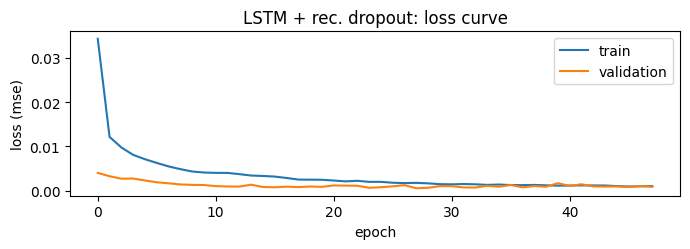

LSTM + rec. dropout    stopped after 48 epochs; best val loss 0.00058


LSTM + rec. dropout    params:   5281   test MAE: 94.3 MW


Restoring model weights from the end of the best epoch: 50.


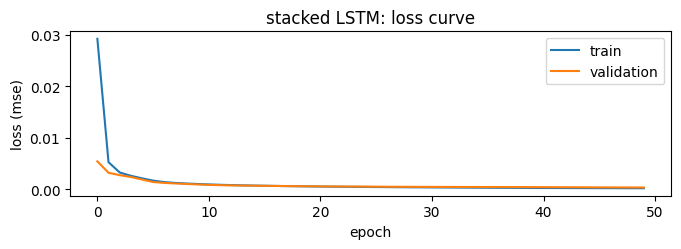

stacked LSTM           stopped after 50 epochs; best val loss 0.00033


stacked LSTM           params:   8401   test MAE: 58.4 MW


In [9]:
keras.utils.set_random_seed(5509)   # re-seed before EVERY model, not just at import
drop = Sequential()
drop.add(Input(shape=(n_steps, n_features)))
drop.add(LSTM(32, dropout=0.1, recurrent_dropout=0.2))
drop.add(Dense(1))
drop, pred_drop, mae_drop = fit(drop, "LSTM + rec. dropout")

keras.utils.set_random_seed(5509)   # re-seed before EVERY model, not just at import
stack = Sequential()
stack.add(Input(shape=(n_steps, n_features)))
stack.add(LSTM(32, return_sequences=True))
stack.add(LSTM(16))
stack.add(Dense(1))
stack, pred_stack, mae_stack = fit(stack, "stacked LSTM")

# Model 5 · `Bidirectional`

**Two independent copies of the layer.** One reads the 24 hours oldest → newest, the other newest → oldest, and
their final hidden states are **concatenated**. So there is no new formula: count one LSTM the way you always do,
then **double it**.

```
LSTM(32)                  4 * [32(32 + 8) + 32]  =  5,248
Bidirectional(LSTM(32))   2 * 5,248              = 10,496
```

| layer | output shape | parameters | |
| :-- | :-- | --: | :-- |
| `Bidirectional(LSTM(32))` | `(64,)` | 10,496 | = 2 x 5,248 |
| `Dense(1)` | `(1,)` | 65 | 64 inputs, not 32 |
| | | **10,561** | |

**Is reading backwards cheating?** No. Both passes read **the same 24 rows**, all of them before the target
hour; only the order differs.

The real costs are **double the parameters** and **no streaming**: the backward pass cannot start until the last
hour of the window has arrived.

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 64)             │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,561 (41.25 KB)

 Trainable params: 10,561 (41.25 KB)

 Non-trainable params: 0 (0.00 B)

Restoring model weights from the end of the best epoch: 50.


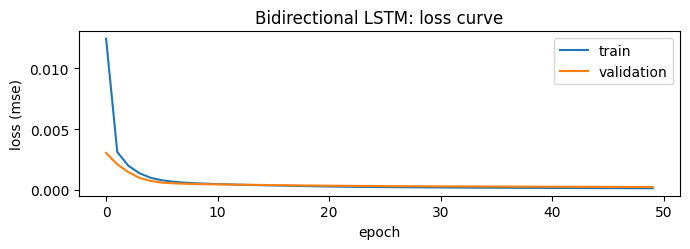

Bidirectional LSTM     stopped after 50 epochs; best val loss 0.00024


Bidirectional LSTM     params:  10561   test MAE: 52.5 MW


In [10]:
keras.utils.set_random_seed(5509)   # re-seed before EVERY model, not just at import
bi = Sequential()
bi.add(Input(shape=(n_steps, n_features)))
bi.add(Bidirectional(LSTM(32)))
bi.add(Dense(1))
bi.summary()
bi, pred_bi, mae_bi = fit(bi, "Bidirectional LSTM")

## The bake-off

In [11]:
pd.Series({"persistence": baselines.iloc[2], "seasonal naive": baselines.iloc[1],
           "plain LSTM": mae_plain, "ConvLSTM": mae_conv, "LSTM + rec. dropout": mae_drop, "stacked LSTM": mae_stack, "Bidirectional LSTM": mae_bi},
          name="test MAE, 1h ahead (MW)").round(1).sort_values()

ConvLSTM                50.1
plain LSTM              50.7
Bidirectional LSTM      52.5
stacked LSTM            58.4
LSTM + rec. dropout     94.3
persistence            129.0
seasonal naive         227.1
Name: test MAE, 1h ahead (MW), dtype: float64

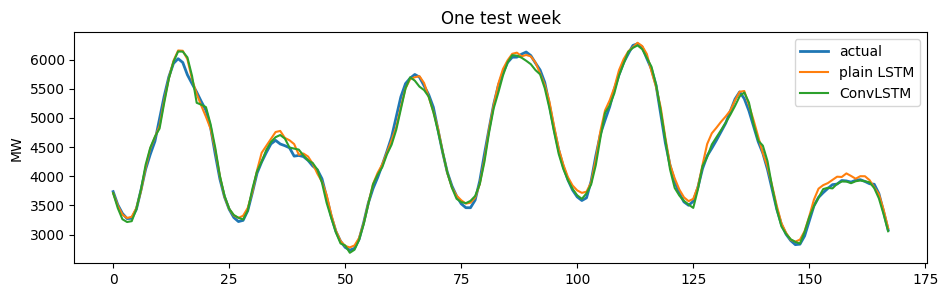

In [12]:
i0 = 24*7*28
plt.figure(figsize=(11, 3))
plt.plot(y_true[i0:i0+24*7], label="actual", lw=2)
plt.plot(pred_plain[i0:i0+24*7], label="plain LSTM")
plt.plot(pred_conv[i0:i0+24*7], label="ConvLSTM")
plt.title("One test week")
plt.ylabel("MW")
plt.legend()
plt.show()

## The scoreboard

Every model next to the baselines it had to beat. The number that matters is not the MAE itself - it is the gap
between a model and **seasonal naive**, because "same hour yesterday" is free and already very good on a load
series.

In [13]:
board = pd.concat([baselines, pd.Series(scores, name="test MAE (MW)")]).sort_values()
display(board.to_frame())
best, naive = board.index[0], baselines["seasonal naive (same hour yday)"]
print(f"best: {best} at {board.iloc[0]:.1f} MW")
print(f"seasonal naive: {naive:.1f} MW  ->  the best model is {100*(naive-board.iloc[0])/naive:+.0f}% on that baseline")

,test MAE (MW)
ConvLSTM,50.1
plain LSTM,50.7
Bidirectional LSTM,52.5
stacked LSTM,58.4
LSTM + rec. dropout,94.3
persistence (last hour),129.0
seasonal naive (same hour yday),227.1
mean-only,563.3


best: ConvLSTM at 50.1 MW
seasonal naive: 227.1 MW  ->  the best model is +78% on that baseline


## Save the model and use it again

In [14]:
convlstm.save('E3_Advanced_Demand_RNN.keras')
reloaded = load_model('E3_Advanced_Demand_RNN.keras')
print("reloaded model reproduces the predictions:", np.allclose(convlstm.predict(X_test[:5], verbose=0), reloaded.predict(X_test[:5], verbose=0)))

reloaded model reproduces the predictions: True


## On your own

- Change `kernel_size` to 6 and `pool_size` to 4. Trace the shapes by hand *before* you run `summary()`.
- Put two `Conv1D` layers in front of the LSTM. Does the sequence get too short to be useful?
- Re-run the bake-off with `n_steps = 168`. Which of these architectures benefits from a longer window?